# REGIME-SHIFT — Stage 1: Data Foundation
### India Macro-Aware Tactical Allocation Engine

| Parameter | Decision |
|-----------|----------|
| **Backtest window** | Jan 2010 → Dec 2023 (walk-forward training set) |
| **Holdout set** | Jan 2024 → Dec 2024 — *locked, do not inspect until Stage 7* |
| **Execution ETFs** | NIFTYBEES · JUNIORBEES · GILTBEES · GOLDBEES · LIQUIDBEES |
| **Signal sources** | `^NSEI` · `USDINR=X` · `^NSEIVIX` · FRED `INDIRLTLT01STM` |
| **HMM features** | 5 features — no BankNifty, no PE ratio in v1 |
| **LIQUIDBEES** | local parquet prices; fallback 6.5 % / 252 if annualised return outside 3–9 % |

---
**What this notebook does (in order):**
1. Loads raw data from local parquet files in `dataset/`  
2. Validates LIQUIDBEES returns; applies fallback if needed  
3. Builds the NSE trading calendar and aligns every series to it  
4. Engineers the 5 HMM signal features at **monthly** frequency (last NSE trading day of each month)  
5. Computes monthly ETF returns (used in Stages 4–6)  
6. Performs data-quality assertions  
7. Produces a diagnostic 6-panel visualisation  
8. Saves everything to `data/` for downstream stages

> ⚠️ **Never** use `data/holdout_*` files before Stage 7.

In [1]:
# ── Run once; comment out after first execution ────────────────────────────
import subprocess, sys

PKGS = [
    "pandas_market_calendars>=4.3.1",
    "matplotlib>=3.7",
    "seaborn>=0.12",
]
for p in PKGS:
    subprocess.check_call([sys.executable, "-m", "pip", "install", p, "-q"])

print("✓ Packages ready")

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


✓ Packages ready


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [2]:
import warnings, os, json
from pathlib import Path
from datetime import datetime

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
# yfinance is no longer used at runtime — all data loads from disk.
# The import is kept optional so the notebook works even if yfinance
# is not installed in this environment.
try:
    import yfinance as yf
    _yf_version = yf.__version__
except ImportError:
    yf = None
    _yf_version = "not installed (not needed — data loads from disk)"

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

print(f"pandas   {pd.__version__}")
print(f"yfinance {_yf_version}")

pandas   2.3.3
yfinance 1.2.0


/Users/kushagraverma/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
# ── Date windows ──────────────────────────────────────────────────────────────
RAW_START      = "2009-06-01"
BACKTEST_START = "2010-01-01"
BACKTEST_END   = "2023-12-31"
HOLDOUT_START  = "2024-01-01"
HOLDOUT_END    = "2024-12-31"
RAW_END        = HOLDOUT_END

# ── Where your downloaded parquet files live ───────────────────────────────────
# All files are in the SAME folder as this notebook.
# Path(".") means "current directory" — no subdirectory needed.
DATASET_DIR = Path(".")

# ── Execution ETFs ─────────────────────────────────────────────────────────────
ASSET_NAMES = ["NIFTYBEES", "JUNIORBEES", "GOLDBEES", "LIQUIDBEES"]

# ── Signal assets ──────────────────────────────────────────────────────────────
# (tickers kept for reference only — data loads from disk, not yfinance)
SIGNAL_TICKERS = {"NSEI": "^NSEI", "USDINR": "USDINR=X", "INDIAVIX": "^NSEIVIX"}

# ── Risk & cost parameters ─────────────────────────────────────────────────────
RISK_FREE_ANNUAL = 0.065
TC_EQUITY_BPS    = 10
TC_OTHER_BPS     = 5
TC_ONE_WAY = np.array([10, 10, 5, 5]) / 10_000  # NIFTYBEES, JUNIORBEES, GOLDBEES, LIQUIDBEES

# ── LIQUIDBEES validation ──────────────────────────────────────────────────────
LIQ_ANN_MIN          = 0.02  # 2%: accounts for COVID repo rate cuts (2020-2021)
LIQ_ANN_MAX          = 0.09
LIQ_FALLBACK_ANNUAL  = 0.065

# ── Output directory ───────────────────────────────────────────────────────────
DATA_DIR = Path("data")
(DATA_DIR / "daily").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "monthly").mkdir(parents=True, exist_ok=True)

# ── Feature engineering parameters ────────────────────────────────────────────
# All 5 HMM features use a rolling z-score (not expanding).
# Rolling window = 252 trading days ≈ 12 months.
# This ensures a bad month is measured relative to the PAST YEAR, not all-time
# history — so 2021 bull months look bullish even after the 2020 COVID spike.
ROLLING_WINDOW      = 252   # trading days (~12 months)
ROLLING_MIN_PERIODS = 63    # minimum 3 months before first valid z-score

# ── Known data gaps (flagged here so they are visible up front) ────────────────
# GSEC_10Y  : FRED series starts 2011-12 (monthly).
#             After 1-month lag + 21-day diff, gsec_mom_z is first valid ~2012-03.
#             VIX data starts 2010-07-19.
# Impact    : HMM features are complete from ~2013-01 onward.
#             ETF returns are complete (all 4 assets) from backtest start.
# Action    : Stage 2 will use only rows where ALL features AND returns are non-NaN.

print("✓ Config loaded")
print(f"  Training  : {BACKTEST_START}  →  {BACKTEST_END}")
print(f"  Holdout   : {HOLDOUT_START}  →  {HOLDOUT_END}")
print(f"  Files dir : {DATASET_DIR.resolve()}")
print(f"  Assets    : {ASSET_NAMES}")
print(f"  TC (bps)  : equity={TC_EQUITY_BPS}, other={TC_OTHER_BPS}")
print()
print("  ⚠  Data gaps to be aware of:")
print("     GSEC_10Y  — FRED series from 2011-12   (earlier months = NaN)")
print("     VIX       — NSE series from 2010-07-19 (earlier months = NaN)")


✓ Config loaded
  Training  : 2010-01-01  →  2023-12-31
  Holdout   : 2024-01-01  →  2024-12-31
  Files dir : /Users/kushagraverma/reg-full
  Assets    : ['NIFTYBEES', 'JUNIORBEES', 'GOLDBEES', 'LIQUIDBEES']
  TC (bps)  : equity=10, other=5

  ⚠  Data gaps to be aware of:
     GSEC_10Y  — FRED series from 2011-12   (earlier months = NaN)
     VIX       — NSE series from 2010-07-19 (earlier months = NaN)


## Section 1 — Download Raw Data

In [4]:
# ── Utility: strip timezone ────────────────────────────────────────────────────
def _strip_tz(df):
    if hasattr(df.index, "tz") and df.index.tz is not None:
        df.index = df.index.tz_convert("UTC").tz_localize(None)
    df.index = pd.to_datetime(df.index).normalize()
    return df


def _load_file(path: Path, col_name: str) -> pd.Series:
    """
    Load a single-column parquet or CSV. Handles:
      • Normal parquet  : DatetimeIndex, one value column
      • VIX parquet     : RangeIndex with plain 'Date' column + OHLCV columns
    """
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        raise FileNotFoundError(f"{path} not found or empty")

    if path.suffix == ".parquet":
        df = pd.read_parquet(path)
    else:
        try:
            df = pd.read_csv(path, index_col=0, parse_dates=True, encoding="utf-8-sig")
        except Exception:
            df = pd.read_csv(path, index_col=0, parse_dates=True)

    # Promote Date column to index if present (combined_india_vix style)
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")

    df = _strip_tz(df)

    # Drop duplicate dates — NSE historical CSVs/parquets occasionally contain
    # the same calendar date more than once (e.g. combined_india_vix.parquet).
    # Keep the last occurrence so the most recent intraday value wins.
    if df.index.duplicated().any():
        n_dups = df.index.duplicated().sum()
        df = df[~df.index.duplicated(keep="last")]

    df.index.name = "Date"

    if col_name in df.columns:
        return df[col_name].astype(float).rename(col_name)
    elif "Close" in df.columns:
        return df["Close"].astype(float).rename(col_name)
    else:
        return df.iloc[:, 0].astype(float).rename(col_name)


# ── ETF file locations — all files are in DATASET_DIR (same folder as notebook)
ETF_FILE_CANDIDATES = {
    "NIFTYBEES" : [DATASET_DIR / "NIFTYBEES.parquet",  DATASET_DIR / "NIFTYBEES.csv"],
    "JUNIORBEES": [DATASET_DIR / "JUNIORBEES.parquet", DATASET_DIR / "JUNIORBEES.csv"],
    "GOLDBEES"  : [DATASET_DIR / "GOLDBEES.parquet",   DATASET_DIR / "GOLDBEES.csv"],
    "LIQUIDBEES": [DATASET_DIR / "LIQUIDBEES.parquet", DATASET_DIR / "LIQUIDBEES.csv"],
}

# ── Load all ETFs ──────────────────────────────────────────────────────────────
print("Loading ETF prices from disk …")
etf_prices_raw = {}

for name, candidates in ETF_FILE_CANDIDATES.items():
    loaded = False
    for path in candidates:
        try:
            s = _load_file(path, name)
            etf_prices_raw[name] = s
            n_na = s.isna().sum()
            print(f"  ✓ {name:12s}  rows={len(s):5d}  "
                  f"{s.dropna().index[0].date()} → {s.dropna().index[-1].date()}  "
                  f"NaN={n_na}")
            loaded = True
            break
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"    ⚠ {path}: {e}")
    if not loaded:
        print(f"  ✗ {name:12s}  NOT FOUND — expected: {candidates[0]}")

missing = [n for n in ASSET_NAMES if n not in etf_prices_raw]
if missing:
    raise FileNotFoundError(
        f"Missing ETF files: {missing}\n"
        f"Make sure the .parquet files are in the same folder as this notebook."
    )


etf_prices_raw = pd.DataFrame(etf_prices_raw)
print(f"\n✓ ETF matrix: {etf_prices_raw.shape}")
etf_prices_raw.tail(3)


Loading ETF prices from disk …
  ✓ NIFTYBEES     rows= 3845  2009-05-31 → 2024-12-29  NaN=0
  ✓ JUNIORBEES    rows= 3845  2009-05-31 → 2024-12-29  NaN=0
  ✓ GOLDBEES      rows= 3844  2009-05-31 → 2024-12-29  NaN=0
  ✓ LIQUIDBEES    rows= 3845  2009-05-31 → 2024-12-29  NaN=0

✓ ETF matrix: (3846, 4)


,NIFTYBEES,JUNIORBEES,GOLDBEES,LIQUIDBEES
Date,,,,
2024-12-25,265.6700,738.2200,64.0000,963.8069
2024-12-26,266.3900,733.0400,64.2100,963.7974
2024-12-29,264.3700,727.5000,64.0000,963.7974


In [5]:
# ── Signal file locations — same folder as notebook ───────────────────────────
SIGNAL_FILE_CANDIDATES = {
    "NSEI"  : [DATASET_DIR / "NSEI.parquet",   DATASET_DIR / "NSEI.csv"],
    "USDINR": [DATASET_DIR / "USDINR.parquet", DATASET_DIR / "USDINR.csv"],
}

VIX_CANDIDATES = [
    DATASET_DIR / "combined_india_vix.parquet",  # NSE download (RangeIndex + Date col)
    DATASET_DIR / "INDIAVIX.parquet",
    DATASET_DIR / "INDIAVIX.csv",
]

# ── Load NSEI and USDINR ───────────────────────────────────────────────────────
print("Loading signal assets from disk …")
signal_raw = {}

for name, candidates in SIGNAL_FILE_CANDIDATES.items():
    for path in candidates:
        try:
            s = _load_file(path, name)
            signal_raw[name] = s
            print(f"  ✓ {name:10s}  rows={len(s):5d}  "
                  f"{s.dropna().index[0].date()} → {s.dropna().index[-1].date()}")
            break
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"    ⚠ {path}: {e}")
    else:
        print(f"  ✗ {name}  NOT FOUND — expected: {SIGNAL_FILE_CANDIDATES[name][0]}")

# ── Load India VIX ─────────────────────────────────────────────────────────────
print("  Loading INDIAVIX …")
vix_loaded = False
for path in VIX_CANDIDATES:
    try:
        s = _load_file(path, "INDIAVIX")
        signal_raw["INDIAVIX"] = s
        print(f"  ✓ INDIAVIX    rows={len(s):5d}  "
              f"{s.dropna().index[0].date()} → {s.dropna().index[-1].date()}")
        vix_loaded = True
        break
    except FileNotFoundError:
        continue
    except Exception as e:
        print(f"    ⚠ {path}: {e}")

if not vix_loaded:
    raise FileNotFoundError(
        "India VIX not found.\n"
        f"Expected: {DATASET_DIR / 'combined_india_vix.parquet'}"
    )

# ── VIX inception check — NSE VIX launched 2010-07-19 ────────────────────────
vix_start = signal_raw["INDIAVIX"].dropna().index.min()
assert vix_start >= pd.Timestamp("2010-01-01"), (
    f"VIX data starts {vix_start.date()} which is before NSE VIX launch (Jul 2010). "
    "Check the source file."
)
print(f"  ✓ VIX earliest obs: {vix_start.date()}")

missing_sig = [n for n in ["NSEI", "USDINR", "INDIAVIX"] if n not in signal_raw]
if missing_sig:
    raise FileNotFoundError(f"Missing signal files: {missing_sig}")

signal_raw = pd.DataFrame(signal_raw)
print(f"\n✓ Signal matrix: {signal_raw.shape}")
signal_raw.tail(3)


Loading signal assets from disk …
  ✓ NSEI        rows= 3825  2009-05-31 → 2024-12-29
  ✓ USDINR      rows= 4060  2009-05-31 → 2024-12-30
  Loading INDIAVIX …
  ✓ INDIAVIX    rows= 3585  2010-07-19 → 2024-12-31
  ✓ VIX earliest obs: 2010-07-19

✓ Signal matrix: (4803, 3)


,NSEI,USDINR,INDIAVIX
Date,,,
2024-12-29,23644.9004,NaN,NaN
2024-12-30,NaN,85.3860,13.9725
2024-12-31,NaN,NaN,14.4475


In [6]:
FRED_SERIES = "INDIRLTLT01STM"

GSEC_CANDIDATES = [
    DATASET_DIR / "GSEC_10Y.parquet",   # same folder as notebook
    DATASET_DIR / "GSEC_10Y.csv",
]

def _load_fred_gsec(series: str, start: str, end: str) -> pd.Series:
    try:
        import pandas_datareader.data as web
        df = web.DataReader(series, "fred", start=start, end=end)
        s  = df[series].dropna()
        print(f"  ✓ FRED via pandas_datareader: {len(s)} monthly obs")
        return s
    except Exception as e:
        print(f"  pandas_datareader failed ({e}), trying direct CSV …")
    try:
        url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}"
        df  = pd.read_csv(url, index_col=0, parse_dates=True)
        df.columns = [series]
        df  = df.replace(".", np.nan).astype(float)
        s   = df[series].dropna()
        s   = s[(s.index >= start) & (s.index <= end)]
        print(f"  ✓ FRED direct CSV: {len(s)} monthly obs")
        return s
    except Exception as e:
        raise RuntimeError(
            f"Both FRED methods failed: {e}\n"
            "Manual fix: save INDIRLTLT01STM.csv from fred.stlouisfed.org "
            f"as {DATASET_DIR / 'GSEC_10Y.csv'}"
        )

print("Loading G-Sec 10Y yield …")
gsec_monthly = None

for path in GSEC_CANDIDATES:
    try:
        s = _load_file(path, "GSEC_10Y")
        s = s.dropna()
        if len(s) < 12:
            print(f"  ⚠ {path}: only {len(s)} rows — skipping")
            continue
        gsec_monthly = s
        print(f"  ✓ Loaded from disk: {len(s)} obs  "
              f"{s.index[0].date()} → {s.index[-1].date()}")
        break
    except FileNotFoundError:
        continue
    except Exception as e:
        print(f"  ⚠ {path}: {e}")

if gsec_monthly is None:
    print("  No local file found — downloading from FRED …")
    gsec_monthly = _load_fred_gsec(FRED_SERIES, RAW_START, RAW_END)

# 1-month publication lag + daily forward-fill
gsec_lagged = gsec_monthly.shift(1)
gsec_daily  = gsec_lagged.resample("D").ffill().ffill()
gsec_daily.name = "GSEC_10Y"

print(f"  Daily series: {len(gsec_daily)} rows  "
      f"[{gsec_daily.min():.2f}% – {gsec_daily.max():.2f}%]")
print(f"  ⚠  GSEC monthly data starts {gsec_monthly.dropna().index[0].date()} "
      f"→ gsec_mom_z feature available from ~2012-03")


Loading G-Sec 10Y yield …
  ✓ Loaded from disk: 157 obs  2011-12-01 → 2024-12-01
  Daily series: 4750 rows  [5.81% – 8.99%]
  ⚠  GSEC monthly data starts 2011-12-01 → gsec_mom_z feature available from ~2012-03


## Section 2 — LIQUIDBEES Validation

In [7]:
# LIQUIDBEES distributes daily income as fractional units → NAV ≈ ₹1,000.
# auto_adjust=True on yfinance should capture dividend reinvestment.
# Validation: annualised return must be in [3 %, 9 %] to be credible.

def validate_liquidbees(prices: pd.Series) -> pd.Series:
    """
    Given a LIQUIDBEES price series (auto-adjusted), return daily returns.
    If the annualised geometric return is outside [LIQ_ANN_MIN, LIQ_ANN_MAX],
    fall back to a flat RBI repo rate proxy (6.5 % / 252 per day).
    """
    daily_ret = prices.pct_change().dropna()
    geo_mean  = (1 + daily_ret).prod() ** (252 / len(daily_ret)) - 1

    print(f"  LIQUIDBEES annualised return (auto_adjust): {geo_mean:.2%}")

    if LIQ_ANN_MIN <= geo_mean <= LIQ_ANN_MAX:
        print(f"  ✓ Within [{LIQ_ANN_MIN:.0%}, {LIQ_ANN_MAX:.0%}] — using yfinance series")
        return daily_ret
    else:
        print(f"  ✗ Outside [{LIQ_ANN_MIN:.0%}, {LIQ_ANN_MAX:.0%}] — "
              f"switching to RBI repo fallback ({LIQ_FALLBACK_ANNUAL:.1%} / 252)")
        # Reconstruct a flat daily return on the same date index
        fallback = pd.Series(LIQ_FALLBACK_ANNUAL / 252,
                             index=daily_ret.index,
                             name="LIQUIDBEES")
        return fallback


liq_returns_validated = validate_liquidbees(etf_prices_raw["LIQUIDBEES"])

# Spot-check: compound over 2023 → should be ~6–7 %
liq_2023 = liq_returns_validated["2023"]
ann_2023  = (1 + liq_2023).prod() ** (252 / len(liq_2023)) - 1
print(f"  LIQUIDBEES annualised return in 2023: {ann_2023:.2%}  (expect ~6–7 %)")

  LIQUIDBEES annualised return (auto_adjust): 3.76%
  ✓ Within [2%, 9%] — using yfinance series
  LIQUIDBEES annualised return in 2023: 6.00%  (expect ~6–7 %)


## Section 3 — NSE Calendar & Alignment

In [8]:
def build_nse_calendar(start: str, end: str,
                       nsei_series: pd.Series,
                       cache_path: str = "dataset/nse_calendar_cache.csv") -> pd.DatetimeIndex:
    """
    Reproducibility fix: pandas_market_calendars periodically adds newly
    gazetted NSE holidays to its data, so the SAME (start, end) can return a
    DIFFERENT trading-day count depending on which library version is
    installed. That silently breaks reindexing downstream (misaligned
    lengths -> NaN feature columns in Stage 1-3). We cache the computed
    calendar to disk on first run and reuse it on every subsequent run,
    regardless of library version drift, on this machine or any other that
    receives the cached file.
    """
    cache = Path(cache_path)
    if cache.exists():
        cached = pd.read_csv(cache, parse_dates=["date"])
        days = pd.DatetimeIndex(cached["date"])
        print(f"  NSE calendar loaded from cache ({cache}): {len(days)} trading days")
        return days

    try:
        import pandas_market_calendars as mcal
        nse      = mcal.get_calendar("NSE")
        schedule = nse.schedule(start_date=start, end_date=end)
        days     = mcal.date_range(schedule, frequency="1D")
        days = days.tz_convert("UTC").tz_localize(None).normalize()
        days = pd.DatetimeIndex(days)
        print(f"  NSE calendar via pandas_market_calendars: {len(days)} trading days")
    except Exception as e:
        print(f"  pandas_market_calendars failed ({e}), deriving from ^NSEI …")
        days = nsei_series.dropna().index
        days = days[(days >= start) & (days <= end)]
        print(f"  NSE calendar derived from ^NSEI data: {len(days)} trading days")

    cache.parent.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"date": days}).to_csv(cache, index=False)
    print(f"  Cached NSE calendar -> {cache} (reused on future runs for reproducibility)")
    return days


nse_cal_full = build_nse_calendar(RAW_START, RAW_END, signal_raw["NSEI"])

# VIX inception: NSE launched India VIX on 2010-07-19
vix_start = signal_raw["INDIAVIX"].dropna().index.min()
assert vix_start >= pd.Timestamp("2010-01-01"), (
    f"VIX data starts {vix_start.date()} — before NSE VIX launch (Jul 2010). Verify file."
)
print(f"  ✓ India VIX earliest obs : {vix_start.date()}")
print(f"  ✓ NSE calendar built     : {nse_cal_full[0].date()} → {nse_cal_full[-1].date()}")


  pandas_market_calendars failed (unsupported operand type(s) for |: 'type' and 'NoneType'), deriving from ^NSEI …
  NSE calendar derived from ^NSEI data: 3824 trading days
  Cached NSE calendar -> dataset/nse_calendar_cache.csv (reused on future runs for reproducibility)
  ✓ India VIX earliest obs : 2010-07-19
  ✓ NSE calendar built     : 2009-06-01 → 2024-12-29


In [9]:
def align_to_nse(series: pd.Series, method: str = "ffill",
                 limit: int = 5) -> pd.Series:
    """Reindex to NSE calendar and optionally forward-fill."""
    s = series.reindex(nse_cal_full)
    if method == "ffill":
        s = s.ffill(limit=limit)
    return s


# ETF prices — no forward-fill (NaN = market closed or data gap)
etf_aligned = pd.DataFrame(
    {name: align_to_nse(etf_prices_raw[name], method=None)
     for name in ASSET_NAMES},
    index=nse_cal_full,
)

# Signal assets
nsei_aligned   = align_to_nse(signal_raw["NSEI"],     method=None)
usdinr_aligned = align_to_nse(signal_raw["USDINR"],   method="ffill")
vix_aligned    = align_to_nse(signal_raw["INDIAVIX"], method="ffill", limit=1)
gsec_aligned   = align_to_nse(gsec_daily,             method="ffill")
liq_ret_aligned = liq_returns_validated.reindex(nse_cal_full)

print("Shapes after NSE alignment:")
print(f"  ETF prices   : {etf_aligned.shape}")
print(f"  ^NSEI        : {nsei_aligned.shape}")
print(f"  USDINR       : {usdinr_aligned.shape}")
print(f"  India VIX    : {vix_aligned.shape}")
print(f"  G-Sec 10Y    : {gsec_aligned.shape}")
print(f"  LIQUIDBEES r : {liq_ret_aligned.shape}")



Shapes after NSE alignment:
  ETF prices   : (3824, 4)
  ^NSEI        : (3824,)
  USDINR       : (3824,)
  India VIX    : (3824,)
  G-Sec 10Y    : (3824,)
  LIQUIDBEES r : (3824,)


In [10]:
# Rebalance rule: last NSE trading day of each month.
# This is the sampling point for all monthly features and ETF returns.

# Build a DatetimeIndex of month-end NSE trading days
def last_nse_day_per_month(nse_index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """Return the last trading day of each calendar month."""
    s = pd.Series(nse_index, index=nse_index)
    # Group by year-month, take last
    month_ends = s.groupby(s.dt.to_period("M")).last()
    return pd.DatetimeIndex(month_ends.values)


rebal_dates = last_nse_day_per_month(nse_cal_full)

# Restrict to backtest + holdout window
rebal_dates = rebal_dates[
    (rebal_dates >= BACKTEST_START) & (rebal_dates <= HOLDOUT_END)
]

print(f"Total rebalance dates: {len(rebal_dates)}")
print(f"  First : {rebal_dates[0].date()}")
print(f"  Last  : {rebal_dates[-1].date()}")
print(f"  Sample (last 6): {[d.date() for d in rebal_dates[-6:]]}")

Total rebalance dates: 180
  First : 2010-01-31
  Last  : 2024-12-29
  Sample (last 6): [datetime.date(2024, 7, 31), datetime.date(2024, 8, 29), datetime.date(2024, 9, 30), datetime.date(2024, 10, 31), datetime.date(2024, 11, 28), datetime.date(2024, 12, 29)]


## Section 4 — Feature Engineering

In [11]:
# Monthly ETF returns are computed as the compounded daily return over each
# calendar month, sampled at the last NSE trading day of that month.

def monthly_etf_returns(etf_prices: pd.DataFrame,
                        liq_returns: pd.Series,
                        rebal_dates: pd.DatetimeIndex) -> pd.DataFrame:
    """
    For each ETF: compound daily price-change returns over each month.
    LIQUIDBEES: use the validated daily return series directly.
    """
    # Daily returns for equity ETFs
    etf_daily_ret = etf_prices.pct_change()
    # Replace LIQUIDBEES price-change with validated return
    etf_daily_ret["LIQUIDBEES"] = liq_returns.reindex(etf_daily_ret.index)

    monthly = {}
    for i, end_date in enumerate(rebal_dates):
        # Start of the month: day after previous rebalance date (or RAW_START)
        start_date = rebal_dates[i - 1] + pd.Timedelta(days=1) if i > 0                      else pd.Timestamp(BACKTEST_START)
        # Window: all NSE days from start_date to end_date
        window = etf_daily_ret.loc[start_date:end_date]
        # Compound the daily returns
        period_ret = (1 + window).prod() - 1
        # prod() returns 1.0 for all-NaN windows → 0% return instead of NaN.
        period_ret[window.isna().all()] = np.nan
        monthly[end_date] = period_ret

    df = pd.DataFrame(monthly).T
    df.index.name = "date"
    return df


etf_monthly = monthly_etf_returns(etf_aligned, liq_ret_aligned, rebal_dates)

print(f"Monthly ETF returns: {etf_monthly.shape}  "
      f"(rows=months, cols=assets)")
print(f"  NaN check: {etf_monthly.isna().sum().to_dict()}")
etf_monthly.describe().round(4)

Monthly ETF returns: (180, 4)  (rows=months, cols=assets)
  NaN check: {'NIFTYBEES': 0, 'JUNIORBEES': 0, 'GOLDBEES': 0, 'LIQUIDBEES': 0}


,NIFTYBEES,JUNIORBEES,GOLDBEES,LIQUIDBEES
count,180.0000,180.0000,180.0000,180.0000
mean,0.0102,0.0124,0.0084,0.0031
std,0.0483,0.0538,0.0406,0.0022
min,-0.2510,-0.2098,-0.1054,-0.0000
25%,-0.0174,-0.0165,-0.0214,0.0018
50%,0.0100,0.0109,0.0047,0.0033
75%,0.0377,0.0481,0.0332,0.0044
max,0.1660,0.1832,0.1587,0.0099


In [12]:
# ── Feature definitions ────────────────────────────────────────────────────────
#
# 7 features, all rolling z-scores (window = 252 trading days ≈ 12 months).
#
# The HMM still receives short-horizon stress information, but Stage 1 now also
# saves a slow 126-day trend feature.  Stage 3 can keep the HMM input lean while
# using this slow-trend diagnostic to audit broad bull-market coverage.
#
# Look-ahead: None. All rolling calculations use only [t-252, t].

def rolling_zscore(s: pd.Series,
                   window:      int = ROLLING_WINDOW,
                   min_periods: int = ROLLING_MIN_PERIODS) -> pd.Series:
    """
    Rolling z-score: (x_t - μ_{t-window:t}) / σ_{t-window:t}
    No look-ahead bias — uses only past observations.
    """
    mu  = s.rolling(window=window, min_periods=min_periods).mean()
    std = s.rolling(window=window, min_periods=min_periods).std()
    return (s - mu) / std.replace(0, np.nan)


nifty_daily_ret = nsei_aligned.pct_change()
nifty_21d_ret   = nsei_aligned.pct_change(21)
nifty_126d_ret  = nsei_aligned.pct_change(126)

# 1. Nifty short momentum z-score
feat_nifty_mom_z      = rolling_zscore(nifty_21d_ret)
feat_nifty_mom_z.name = "nifty_mom_z"

# 2. Realised volatility z-score
realized_vol_raw        = nifty_daily_ret.rolling(21).std() * np.sqrt(252)
feat_realized_vol       = rolling_zscore(realized_vol_raw)
feat_realized_vol.name  = "realized_vol_z"

# 3. India VIX z-score
feat_vix_z      = rolling_zscore(vix_aligned)
feat_vix_z.name = "vix_z"

# 4. INR depreciation stress
inr_63d              = usdinr_aligned.pct_change(63)
feat_inr_stress      = rolling_zscore(inr_63d)
feat_inr_stress.name = "inr_stress"

# 5. G-Sec yield momentum z-score
feat_gsec_mom_raw = gsec_aligned.diff(21) * 100
feat_gsec_mom     = rolling_zscore(feat_gsec_mom_raw)
feat_gsec_mom.name = "gsec_mom_z"

# 6. Trend quality z-score
# Risk-adjusted 21-day momentum: 21-day return / realised vol.
trend_quality_raw       = nifty_21d_ret / (realized_vol_raw + 0.001)
feat_trend_quality      = rolling_zscore(trend_quality_raw)
feat_trend_quality.name = "trend_quality_z"

# 7. Slow trend z-score — broad bull-market diagnostic
# 126 trading days ≈ 6 months. This is deliberately slower than nifty_mom_z,
# so years like 2021 remain visibly risk-on even when the last 21 days pause.
feat_nifty_trend_126d      = rolling_zscore(nifty_126d_ret)
feat_nifty_trend_126d.name = "nifty_trend_126d_z"

# ── Assemble daily feature DataFrame ──────────────────────────────────────────
# Column order matters for Stage 2/3 configuration:
# [0]=nifty_mom_z [1]=realized_vol_z [2]=vix_z [3]=inr_stress
# [4]=gsec_mom_z  [5]=trend_quality_z [6]=nifty_trend_126d_z
features_daily = pd.concat(
    [feat_nifty_mom_z, feat_realized_vol,
     feat_vix_z, feat_inr_stress, feat_gsec_mom,
     feat_trend_quality, feat_nifty_trend_126d],
    axis=1
).reindex(nse_cal_full)

print(f"Daily feature matrix : {features_daily.shape}  (7 features)")
print(f"Rolling window       : {ROLLING_WINDOW} trading days ({ROLLING_WINDOW//21} months)")
print(f"Min periods          : {ROLLING_MIN_PERIODS} trading days")
print()

print("Spot-check: short momentum vs slow trend")
spot_dates = ["2021-09-30", "2022-06-30", "2020-03-31", "2023-11-30"]
for d in spot_dates:
    try:
        ts = pd.Timestamp(d)
        row = features_daily.loc[ts] if ts in features_daily.index else \
              features_daily.iloc[features_daily.index.get_indexer([ts], method="nearest")[0]]
        print(f"  {d[:7]}  mom_z={row['nifty_mom_z']:+.2f}  "
              f"trend126_z={row['nifty_trend_126d_z']:+.2f}  "
              f"vol_z={row['realized_vol_z']:+.2f}  "
              f"trend_quality_z={row['trend_quality_z']:+.2f}")
    except Exception:
        pass

print()
print(features_daily.head(3).to_string())


Daily feature matrix : (3824, 7)  (7 features)
Rolling window       : 252 trading days (12 months)
Min periods          : 63 trading days

Spot-check: short momentum vs slow trend
  2021-09  mom_z=-0.28  trend126_z=-0.73  vol_z=-0.99  trend_quality_z=-0.09
  2022-06  mom_z=-1.20  trend126_z=-1.48  vol_z=+0.22  trend_quality_z=-1.17
  2020-03  mom_z=-3.20  trend126_z=-4.00  vol_z=+4.97  trend_quality_z=-1.09
  2023-11  mom_z=+1.91  trend126_z=+0.32  vol_z=-1.35  trend_quality_z=+2.39

            nifty_mom_z  realized_vol_z  vix_z  inr_stress  gsec_mom_z  trend_quality_z  nifty_trend_126d_z
Date                                                                                                       
2009-06-01          NaN             NaN    NaN         NaN         NaN              NaN                 NaN
2009-06-02          NaN             NaN    NaN         NaN         NaN              NaN                 NaN
2009-06-03          NaN             NaN    NaN         NaN         NaN         

In [13]:
# Sample daily features at each rebalance date (last NSE trading day per month)
features_monthly = features_daily.reindex(rebal_dates)
features_monthly.index.name = "date"

print(f"Monthly feature matrix : {features_monthly.shape}")
print(f"Feature NaN counts:\n{features_monthly.isna().sum().to_dict()}")
print()

# ── Describe ──────────────────────────────────────────────────────────────────
desc = features_monthly.describe().round(4)
print(desc.to_string())

Monthly feature matrix : (180, 7)
Feature NaN counts:
{'nifty_mom_z': 0, 'realized_vol_z': 0, 'vix_z': 10, 'inr_stress': 0, 'gsec_mom_z': 29, 'trend_quality_z': 0, 'nifty_trend_126d_z': 2}

       nifty_mom_z  realized_vol_z    vix_z  inr_stress  gsec_mom_z  trend_quality_z  nifty_trend_126d_z
count     180.0000        180.0000 170.0000    180.0000    151.0000         180.0000            178.0000
mean       -0.0291         -0.0242  -0.0569      0.1010      0.0664           0.0148             -0.0190
std         1.0575          1.2152   1.2369      1.1805      0.8190           1.0615              1.2627
min        -3.1992         -2.2536  -2.9285     -2.8306     -1.7773          -2.2142             -3.9950
25%        -0.6921         -0.8700  -0.8606     -0.7617     -0.4078          -0.7248             -0.9243
50%        -0.0207         -0.2724  -0.2195      0.0708      0.0830          -0.0937             -0.0819
75%         0.5398          0.4922   0.4903      0.8071      0.5306        

## Section 5 — Train / Holdout Split

In [14]:
# ── Monthly feature split ──────────────────────────────────────────────────────
feat_train = features_monthly[features_monthly.index <= BACKTEST_END].copy()
feat_holdout = features_monthly[features_monthly.index >= HOLDOUT_START].copy()

# ── Monthly ETF return split ───────────────────────────────────────────────────
ret_train   = etf_monthly[etf_monthly.index <= BACKTEST_END].copy()
ret_holdout = etf_monthly[etf_monthly.index >= HOLDOUT_START].copy()

# ── Daily price split (for diagnostic use only) ───────────────────────────────
etf_prices_train   = etf_aligned[etf_aligned.index <= BACKTEST_END].copy()
etf_prices_holdout = etf_aligned[etf_aligned.index >= HOLDOUT_START].copy()

print("Split summary:")
print(f"  feat_train   : {feat_train.shape}  "
      f"{feat_train.index[0].date()} → {feat_train.index[-1].date()}")
print(f"  feat_holdout : {feat_holdout.shape}  "
      f"{feat_holdout.index[0].date()} → {feat_holdout.index[-1].date()}")
print(f"  ret_train    : {ret_train.shape}")
print(f"  ret_holdout  : {ret_holdout.shape}")

# Safety check: no overlap
assert feat_train.index.max() < feat_holdout.index.min(),     "⚠️  Overlap detected between training and holdout sets!"
print("\n✓ No overlap between training and holdout sets.")

Split summary:
  feat_train   : (168, 7)  2010-01-31 → 2023-12-31
  feat_holdout : (12, 7)  2024-01-31 → 2024-12-29
  ret_train    : (168, 4)
  ret_holdout  : (12, 4)

✓ No overlap between training and holdout sets.


## Section 6 — Data Quality Checks

In [15]:
print("=" * 60)
print("DATA QUALITY REPORT")
print("=" * 60)

issues = []

# ── 1. ETF annualised return plausibility ─────────────────────────────────────
print("\n[1] ETF annualised return check (training window):")
for col in ASSET_NAMES:
    r = ret_train[col].dropna()
    ann = (1 + r).prod() ** (12 / len(r)) - 1
    low, high = (0.02, 0.30) if col != "LIQUIDBEES" else (0.03, 0.09)
    flag = "✓" if low <= ann <= high else "✗"
    if flag == "✗":
        issues.append(f"{col} annualised return {ann:.1%} outside [{low:.0%},{high:.0%}]")
    print(f"  {flag} {col:12s}  CAGR={ann:6.1%}  expect=[{low:.0%},{high:.0%}]")

# ── 2. Feature NaN check in training window ───────────────────────────────────
print("\n[2] Feature NaN count in training window:")
for col in feat_train.columns:
    n_nan = feat_train[col].isna().sum()
    n_tot = len(feat_train)
    flag  = "✓" if n_nan / n_tot < 0.05 else "✗"
    if flag == "✗":
        issues.append(f"Feature {col} has >{5}% NaN in training window")
    print(f"  {flag} {col:20s}  NaN={n_nan}/{n_tot}  ({n_nan/n_tot:.1%})")

# ── 3. Date continuity ────────────────────────────────────────────────────────
print("\n[3] Rebalance date coverage:")
expected_months = pd.period_range(BACKTEST_START, BACKTEST_END, freq="M")
actual_months   = feat_train.index.to_period("M")
missing = set(expected_months) - set(actual_months)
flag = "✓" if not missing else "✗"
if missing:
    issues.append(f"Missing rebalance months: {sorted(missing)[:5]}")
print(f"  {flag} Expected {len(expected_months)} months, "
      f"got {len(actual_months)}.  Missing: {len(missing)}")

# ── 4. India VIX start ────────────────────────────────────────────────────────
print("\n[4] India VIX inception check:")
vix_ok = vix_aligned.dropna().index.min() >= pd.Timestamp("2009-03-01")
print(f"  {'✓' if vix_ok else '✗'} VIX earliest obs: "
      f"{vix_aligned.dropna().index.min().date()}  (must be ≥ 2009-03-01)")

# ── 5. Feature scale check ────────────────────────────────────────────────────
# All 5 features are rolling z-scores (12-month window).
# Mean over the full training window should be close to 0 (features are centred
# relative to recent history at each point, so long-run average ≈ 0).
# Std should be close to 1 — any value outside [0.7, 1.4] suggests a scaling issue.
print("\n[5] Feature scale (rolling z-scores — mean ≈ 0, std ≈ 1):")
for col in feat_train.columns:   # dynamic — picks up trend_quality_z automatically
    mu  = feat_train[col].mean()
    std = feat_train[col].std()
    flag_mu  = "✓" if abs(mu)  < 0.5         else "⚠"
    flag_std = "✓" if 0.7 < std < 1.4        else "⚠"
    print(f"  {flag_mu}{flag_std} {col:20s}  mean={mu:+.3f}  std={std:.3f}")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
if issues:
    print(f"⚠  {len(issues)} issue(s) found:")
    for i, iss in enumerate(issues, 1):
        print(f"  {i}. {iss}")
else:
    print("✓  All checks passed. Data is ready for Stage 2.")
print("=" * 60)

DATA QUALITY REPORT

[1] ETF annualised return check (training window):
  ✓ NIFTYBEES     CAGR= 11.5%  expect=[2%,30%]
  ✓ JUNIORBEES    CAGR= 13.0%  expect=[2%,30%]
  ✓ GOLDBEES      CAGR=  8.8%  expect=[2%,30%]
  ✓ LIQUIDBEES    CAGR=  3.7%  expect=[3%,9%]

[2] Feature NaN count in training window:
  ✓ nifty_mom_z           NaN=0/168  (0.0%)
  ✓ realized_vol_z        NaN=0/168  (0.0%)
  ✗ vix_z                 NaN=10/168  (6.0%)
  ✓ inr_stress            NaN=0/168  (0.0%)
  ✗ gsec_mom_z            NaN=28/168  (16.7%)
  ✓ trend_quality_z       NaN=0/168  (0.0%)
  ✓ nifty_trend_126d_z    NaN=2/168  (1.2%)

[3] Rebalance date coverage:
  ✓ Expected 168 months, got 168.  Missing: 0

[4] India VIX inception check:
  ✓ VIX earliest obs: 2010-07-19  (must be ≥ 2009-03-01)

[5] Feature scale (rolling z-scores — mean ≈ 0, std ≈ 1):
  ✓✓ nifty_mom_z           mean=-0.015  std=1.070
  ✓✓ realized_vol_z        mean=-0.071  std=1.204
  ✓✓ vix_z                 mean=-0.114  std=1.212
  ✓✓ inr_stre

## Section 7 — Diagnostic Visualisation

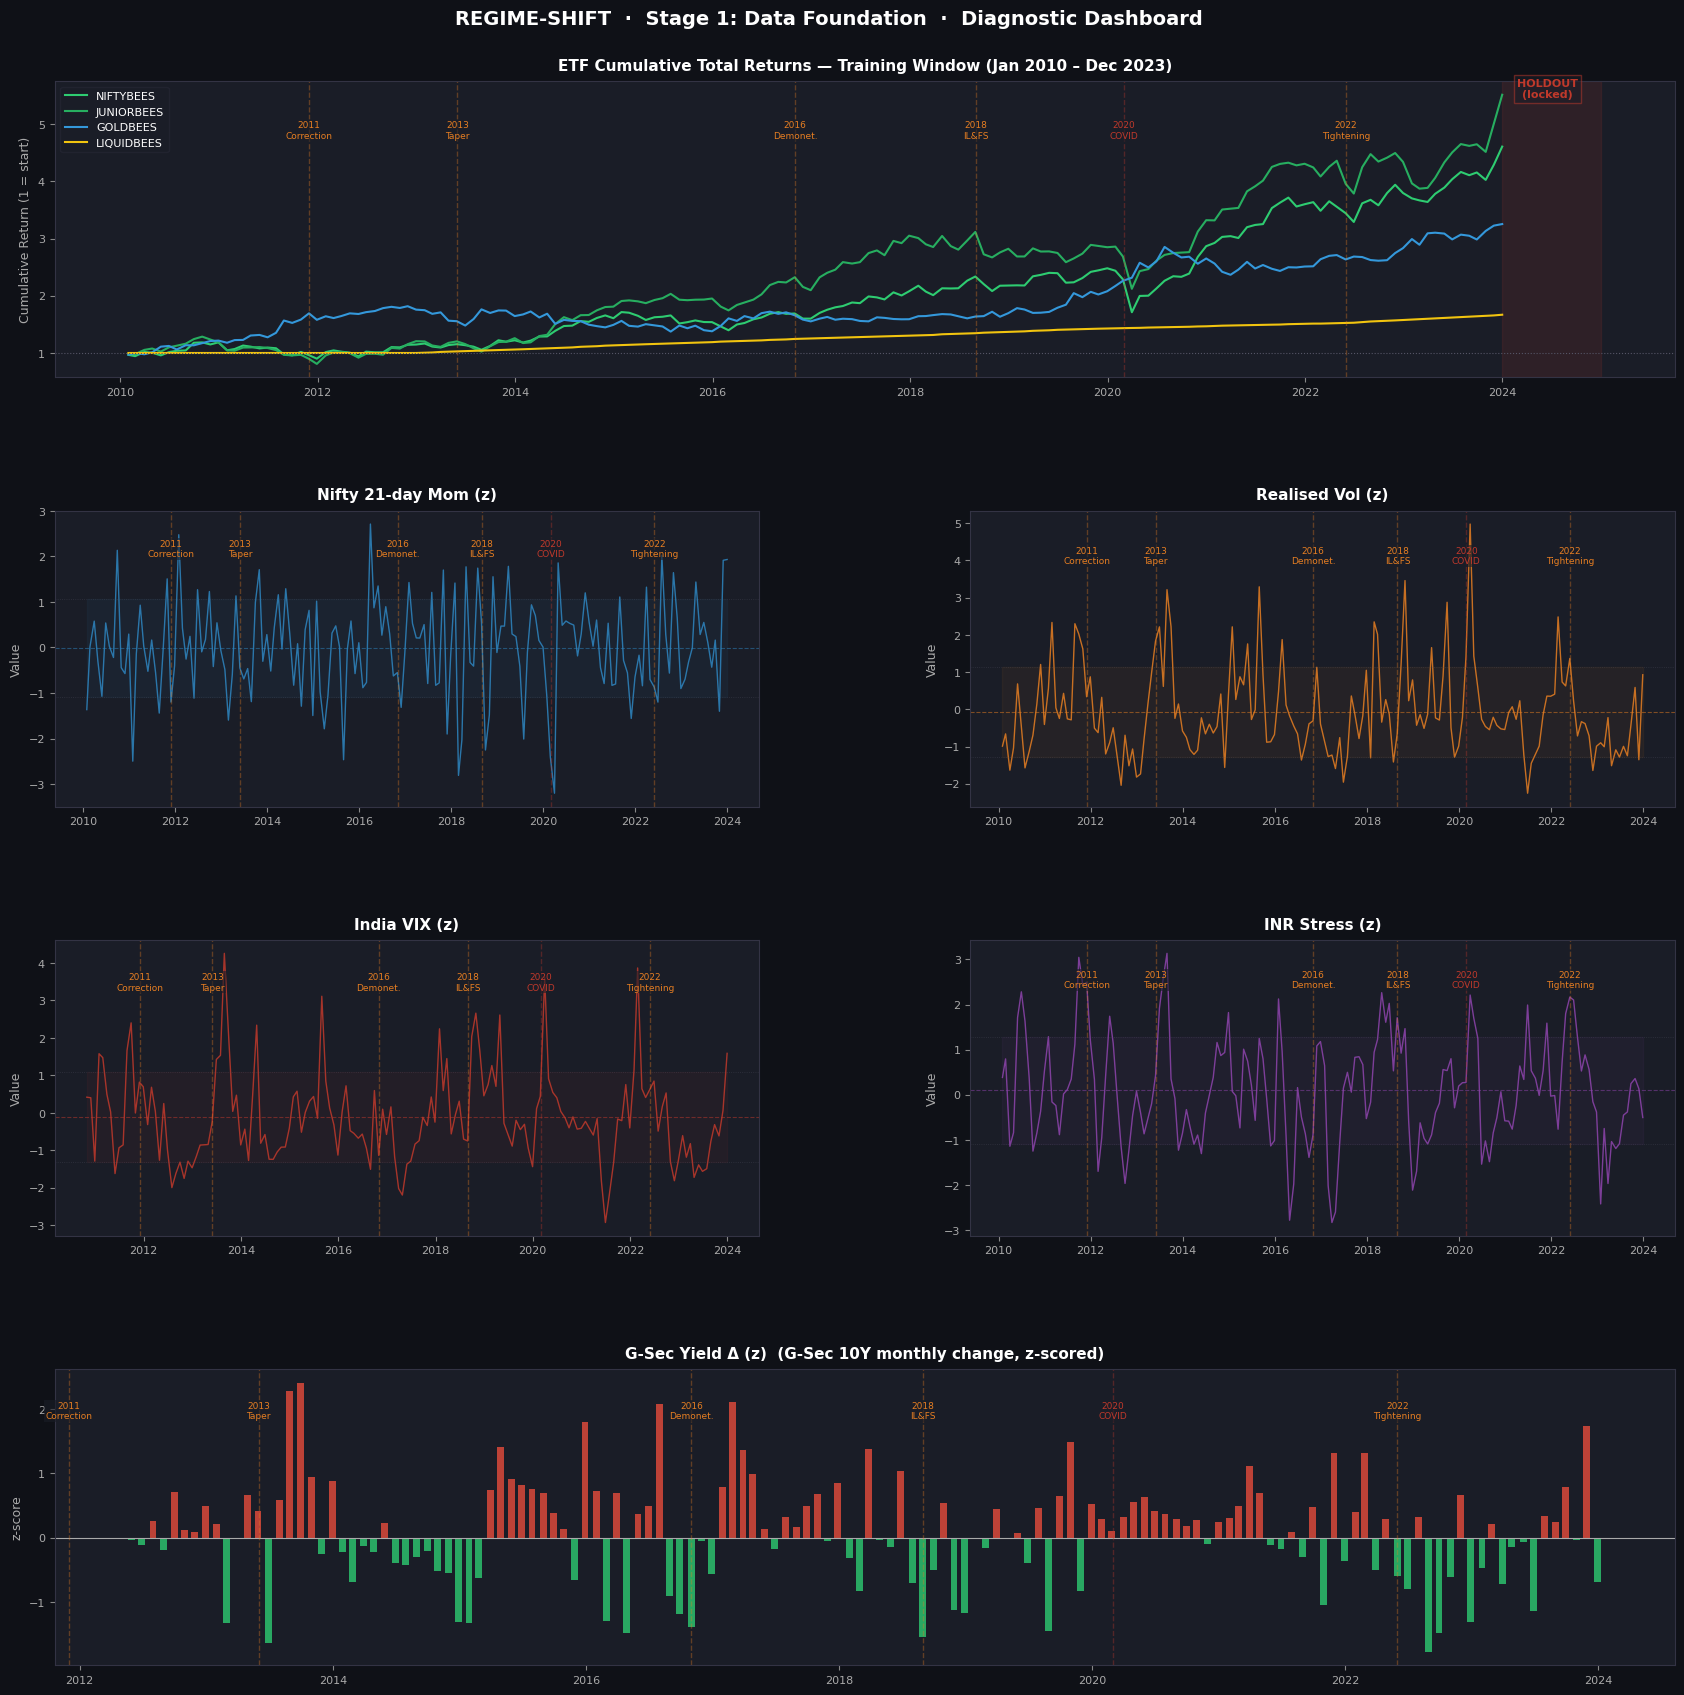

✓ Saved: data/stage1_diagnostic.png


In [16]:
# ── Annotated market-event reference ─────────────────────────────────────────
EVENTS = {
    "2011-12": ("2011\nCorrection", "#E67E22"),
    "2013-06": ("2013\nTaper",      "#E67E22"),
    "2016-11": ("2016\nDemonet.",   "#E67E22"),
    "2018-09": ("2018\nIL&FS",      "#E67E22"),
    "2020-03": ("2020\nCOVID",      "#C0392B"),
    "2022-06": ("2022\nTightening", "#E67E22"),
}

REGIME_COLORS = {"Bull": "#27AE60", "Bear": "#E67E22", "Crisis": "#C0392B"}
FEAT_LABELS = {
    "nifty_mom_z":        "Nifty 21-day Mom (z)",
    "realized_vol_z":     "Realised Vol (z)",
    "vix_z":              "India VIX (z)",
    "inr_stress":         "INR Stress (z)",
    "gsec_mom_z":         "G-Sec Yield Δ (z)",
    "trend_quality_z":    "Trend Quality (z)",
    "nifty_trend_126d_z": "Nifty 126-day Trend (z)",
}
FEAT_COLORS = ["#2E86C1", "#E67E22", "#C0392B", "#8E44AD", "#1E8449", "#16A085", "#F1C40F"]

fig = plt.figure(figsize=(18, 18), facecolor="#0F1117")
gs  = gridspec.GridSpec(4, 2, figure=fig,
                        hspace=0.45, wspace=0.3,
                        left=0.07, right=0.97,
                        top=0.93, bottom=0.05)

TITLE_KW  = dict(color="white", fontsize=11, fontweight="bold", pad=8)
LABEL_KW  = dict(color="#AAAAAA", fontsize=9)
TICK_KW   = dict(axis="both", colors="#888888", labelsize=8)
AX_BG     = "#1A1D27"


def style_ax(ax):
    ax.set_facecolor(AX_BG)
    ax.tick_params(**TICK_KW)
    ax.spines[["top","right","left","bottom"]].set_color("#333344")
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color("#AAAAAA")


def add_events(ax, ymin, ymax):
    for dt_str, (label, color) in EVENTS.items():
        dt = pd.Timestamp(dt_str)
        ax.axvline(dt, color=color, alpha=0.35, lw=1, ls="--")
        ax.text(dt, ymax * 0.88, label, color=color,
                fontsize=6.5, ha="center", va="top", rotation=0,
                bbox=dict(facecolor=AX_BG, edgecolor="none", alpha=0.6, pad=1))


# ── Panel 1: ETF Cumulative Returns (training window) ─────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full-width top panel
style_ax(ax1)
ax1.set_title("ETF Cumulative Total Returns — Training Window (Jan 2010 – Dec 2023)",
              **TITLE_KW)

palette = ["#2ECC71", "#27AE60", "#3498DB", "#F1C40F", "#95A5A6"]
for col, color in zip(ASSET_NAMES, palette):
    r = ret_train[col].dropna()
    cum = (1 + r).cumprod()
    ax1.plot(cum.index, cum.values, label=col, color=color, lw=1.5)

ax1.axhline(1, color="#555566", lw=0.8, ls=":")
ax1.set_ylabel("Cumulative Return (1 = start)", **LABEL_KW)
ax1.legend(loc="upper left", fontsize=8, framealpha=0.3,
           facecolor=AX_BG, edgecolor="#333344", labelcolor="white")

ymin1, ymax1 = ax1.get_ylim()
add_events(ax1, ymin1, ymax1)

# Holdout shading
ax1.axvspan(pd.Timestamp(HOLDOUT_START), pd.Timestamp(HOLDOUT_END),
            alpha=0.12, color="#C0392B",
            label="Holdout (2024)")
ax1.text(pd.Timestamp("2024-06-15"), ymax1 * 0.95,
         "HOLDOUT\n(locked)", color="#C0392B",
         fontsize=8, ha="center", fontweight="bold",
         bbox=dict(facecolor=AX_BG, edgecolor="#C0392B",
                   alpha=0.5, pad=2, linewidth=1))

# ── Panels 2–6: HMM Features ──────────────────────────────────────────────────
feat_order = ["nifty_mom_z", "realized_vol_z", "vix_z", "inr_stress", "gsec_mom_z"]
panel_positions = [(1, 0), (1, 1), (2, 0), (2, 1)]

# Put first 4 features in a 2×2 grid; 5th feature below as half-width
for idx, col in enumerate(feat_order[:4]):
    r, c = panel_positions[idx]
    ax = fig.add_subplot(gs[r, c])
    style_ax(ax)
    ax.set_title(FEAT_LABELS[col], **TITLE_KW)

    series = feat_train[col].dropna()
    ax.plot(series.index, series.values,
            color=FEAT_COLORS[idx], lw=1.0, alpha=0.85)

    # Shade ± 1 std band
    mu_f  = series.mean()
    sd_f  = series.std()
    ax.axhline(mu_f,          color=FEAT_COLORS[idx], lw=0.8, ls="--", alpha=0.5)
    ax.axhline(mu_f + sd_f,   color="#555566", lw=0.6, ls=":", alpha=0.4)
    ax.axhline(mu_f - sd_f,   color="#555566", lw=0.6, ls=":", alpha=0.4)
    ax.fill_between(series.index,
                    mu_f - sd_f, mu_f + sd_f,
                    color=FEAT_COLORS[idx], alpha=0.06)

    add_events(ax, series.min(), series.max())
    ax.set_ylabel("Value", **LABEL_KW)

# 5th feature: G-Sec yield momentum — span bottom row
ax5 = fig.add_subplot(gs[3, :])   # row 3 — own dedicated row, avoids overlap with rows 1-2
style_ax(ax5)
ax5.set_title(FEAT_LABELS["gsec_mom_z"] + "  (G-Sec 10Y monthly change, z-scored)", **TITLE_KW)

s5 = feat_train["gsec_mom_z"].dropna()
ax5.bar(s5.index, s5.values,
        color=np.where(s5.values >= 0, "#E74C3C", "#2ECC71"),
        width=20, alpha=0.8)
ax5.axhline(0, color="#AAAAAA", lw=0.8)
ax5.set_ylabel("z-score", **LABEL_KW)
add_events(ax5, s5.min(), s5.max())

# ── Figure title ──────────────────────────────────────────────────────────────
fig.suptitle(
    "REGIME-SHIFT  ·  Stage 1: Data Foundation  ·  Diagnostic Dashboard",
    color="white", fontsize=14, fontweight="bold", y=0.97
)

plt.savefig(DATA_DIR / "stage1_diagnostic.png",
            dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("✓ Saved: data/stage1_diagnostic.png")


In [17]:
# ── Per-ETF performance summary (training window) ─────────────────────────────
rows = []
for col in ASSET_NAMES:
    r   = ret_train[col].dropna()
    n   = len(r)
    cagr   = (1 + r).prod() ** (12 / n) - 1
    vol    = r.std() * np.sqrt(12)
    rf_mo  = RISK_FREE_ANNUAL / 12
    sharpe = (r.mean() - rf_mo) / (r.std() + 1e-10) * np.sqrt(12)
    cum    = (1 + r).cumprod()
    rmax   = cum.cummax()
    mdd    = ((cum - rmax) / rmax).min()
    rows.append({
        "ETF":           col,
        "CAGR":         f"{cagr:.1%}",
        "Ann. Vol":     f"{vol:.1%}",
        "Sharpe":       f"{sharpe:.2f}",
        "Max DD":       f"{mdd:.1%}",
        "Months":        n,
        "First return":  r.index[0].strftime("%Y-%m"),
        "Last return":   r.index[-1].strftime("%Y-%m"),
    })

print("\nETF Performance Summary — Training Window")
print(pd.DataFrame(rows).to_string(index=False))

# ── Feature summary ────────────────────────────────────────────────────────────
print("\nHMM Feature Summary — Training Window")
print(feat_train.agg(["mean","std","min","max"]).round(3).to_string())


ETF Performance Summary — Training Window
       ETF  CAGR Ann. Vol Sharpe Max DD  Months First return Last return
 NIFTYBEES 11.5%    17.1%   0.35 -31.0%     168      2010-01     2023-12
JUNIORBEES 13.0%    18.8%   0.40 -37.1%     168      2010-01     2023-12
  GOLDBEES  8.8%    14.1%   0.21 -24.4%     168      2010-01     2023-12
LIQUIDBEES  3.7%     0.8%  -3.74  -0.0%     168      2010-01     2023-12

HMM Feature Summary — Training Window
      nifty_mom_z  realized_vol_z   vix_z  inr_stress  gsec_mom_z  trend_quality_z  nifty_trend_126d_z
mean      -0.0150         -0.0710 -0.1140      0.0950      0.0800           0.0430             -0.0300
std        1.0700          1.2040  1.2120      1.1870      0.8360           1.0820              1.2350
min       -3.1990         -2.2540 -2.9280     -2.8310     -1.7770          -2.2140             -3.9950
max        2.7110          4.9750  4.2570      3.1340      2.4120           2.5550              3.3030


## Section 8 — Save to Disk

In [18]:
# ── Save all processed data ────────────────────────────────────────────────────

# Daily ETF prices (full window incl. holdout)
etf_aligned.to_parquet(DATA_DIR / "daily" / "etf_prices.parquet")
etf_aligned.to_csv(   DATA_DIR / "daily" / "etf_prices.csv")

# Daily signal assets
signal_daily = pd.concat(
    [nsei_aligned.rename("NSEI"),
     usdinr_aligned.rename("USDINR"),
     vix_aligned.rename("INDIAVIX"),
     gsec_aligned.rename("GSEC_10Y")],
    axis=1,
)
signal_daily.to_parquet(DATA_DIR / "daily" / "signal_assets.parquet")
signal_daily.to_csv(   DATA_DIR / "daily" / "signal_assets.csv")

# Daily LIQUIDBEES validated returns
liq_ret_aligned.to_frame("LIQUIDBEES_return").to_parquet(
    DATA_DIR / "daily" / "liquidbees_returns.parquet")

# Monthly HMM features — training set
feat_train.to_parquet(DATA_DIR / "monthly" / "hmm_features_train.parquet")
feat_train.to_csv(    DATA_DIR / "monthly" / "hmm_features_train.csv")

# Monthly HMM features — holdout (sealed — use only in Stage 7)
feat_holdout.to_parquet(DATA_DIR / "monthly" / "hmm_features_holdout.parquet")

# Monthly ETF returns — training set
ret_train.to_parquet(DATA_DIR / "monthly" / "etf_returns_train.parquet")
ret_train.to_csv(    DATA_DIR / "monthly" / "etf_returns_train.csv")

# Monthly ETF returns — holdout (sealed)
ret_holdout.to_parquet(DATA_DIR / "monthly" / "etf_returns_holdout.parquet")

# Rebalance dates
pd.Series(rebal_dates, name="rebal_date").to_csv(
    DATA_DIR / "monthly" / "rebalance_dates.csv", index=False)

# Metadata JSON
meta = {
    "created_at":        datetime.now().isoformat(),
    "raw_start":         RAW_START,
    "backtest_start":    BACKTEST_START,
    "backtest_end":      BACKTEST_END,
    "holdout_start":     HOLDOUT_START,
    "holdout_end":       HOLDOUT_END,
    "assets":            ASSET_NAMES,
    "hmm_features":      list(feat_train.columns),
    "n_rebal_train":     int(len(feat_train)),
    "n_rebal_holdout":   int(len(feat_holdout)),
    "risk_free_annual":  RISK_FREE_ANNUAL,
    "tc_one_way_bps":    TC_ONE_WAY.tolist(),   # [NIFTYBEES, JUNIORBEES, GOLDBEES, LIQUIDBEES]
    "liquidbees_source": "yfinance auto_adjust=True (fallback: RBI repo 6.5%/252)",
    "gsec_source":       "FRED INDIRLTLT01STM — monthly series shifted 1 period (≈4–6 week lag), then forward-filled to daily",
    "notes": [
        "JUNIORBEES replaces MID150BEES (MID150BEES inception 2019 — too short)",
        "Nifty PE ratio excluded from v1 feature vector",
        "BankNifty excluded — correlation with NSEI ~0.87, marginal info",
        "Feature z-scoring: 12-month ROLLING window (252 trading days, min 63) — not expanding",
        "6th feature added: trend_quality_z = rolling_zscore(21d_ret / realized_vol) — risk-adjusted momentum",
        "HMM refit: annual, expanding window",
        "Regime assignment: hard Viterbi",
        "Objective: min variance, all 3 regimes, different weight bounds",
    ]
}
with open(DATA_DIR / "metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved files:")
for p in sorted(DATA_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        print(f"  {str(p):<50s}  {size_kb:6.1f} KB")

print("\n✓ Stage 1 complete. All data saved to data/")
print("  → Load in Stage 2 with:")
print("    feat_train = pd.read_parquet('data/monthly/hmm_features_train.parquet')")
print("    ret_train  = pd.read_parquet('data/monthly/etf_returns_train.parquet')")

Saved files:
  data/daily/etf_prices.csv                            309.5 KB
  data/daily/etf_prices.parquet                        119.3 KB
  data/daily/liquidbees_returns.parquet                 42.2 KB
  data/daily/signal_assets.csv                         209.6 KB
  data/daily/signal_assets.parquet                     101.5 KB
  data/metadata.json                                     1.4 KB
  data/monthly/etf_returns_holdout.parquet               4.1 KB
  data/monthly/etf_returns_train.csv                    15.3 KB
  data/monthly/etf_returns_train.parquet                10.8 KB
  data/monthly/hmm_features_holdout.parquet              6.2 KB
  data/monthly/hmm_features_train.csv                   23.7 KB
  data/monthly/hmm_features_train.parquet               17.0 KB
  data/monthly/rebalance_dates.csv                       1.9 KB
  data/stage1_diagnostic.png                           532.7 KB

✓ Stage 1 complete. All data saved to data/
  → Load in Stage 2 with:
    feat_train = pd.

## Stage 1 Complete — Handoff to Stage 2

### Files produced

| File | Contents | Used in |
|------|----------|---------|
| `data/monthly/hmm_features_train.parquet` | 5 HMM features × 168 months | Stage 2 (HMM) |
| `data/monthly/etf_returns_train.parquet` | 5 ETF monthly returns × 168 months | Stage 4 (optimizer) |
| `data/monthly/hmm_features_holdout.parquet` | ⚠️ SEALED — do not open until Stage 7 | Stage 7 only |
| `data/monthly/etf_returns_holdout.parquet` | ⚠️ SEALED — do not open until Stage 7 | Stage 7 only |
| `data/daily/etf_prices.parquet` | Daily adjusted ETF prices | Stage 4 (cost calc) |
| `data/daily/signal_assets.parquet` | Daily NSEI, USDINR, VIX, G-Sec | Diagnostics |
| `data/metadata.json` | Config + design decisions | All stages |

### What Stage 2 receives
- `feat_train`: shape `(168, 5)` — monthly HMM input matrix
- `ret_train`:  shape `(168, 5)` — monthly ETF returns for covariance estimation
- **No future data has been seen.** The holdout files are saved but not inspected.

### Stage 2 agenda
1. ADF / KPSS stationarity tests on all 5 features  
2. Within-regime correlation analysis (check for >0.85 pairwise correlation)  
3. BIC/AIC grid search over `n_states ∈ {2,3,4}` × `covariance_type ∈ {full, diag, tied}`  
4. Lock hyperparameters from training-data BIC before any walk-forward execution  
5. Implement walk-forward HMM loop with annual refit + state alignment